<a href="https://colab.research.google.com/github/Abhii-00/ai_ml_lab/blob/main/decision_tree(ID3_algorithm).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Titanic_Cleaned.csv to Titanic_Cleaned.csv


In [8]:
df = pd.read_csv("Titanic_Cleaned.csv")

In [9]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked  FamilySize  
0      0         A/5 21171   7.2500  Unknown        S           2  
1      0          PC 17599  71.2833      C85        C           2  
2      0  STON/O2. 3101282   7.9250  Unknown        S           1  
3      0            113803  53.1000     C123    

In [10]:
df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print(df.head())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare    Cabin  FamilySize  Sex_male  Embarked_Q  \
0         A/5 21171   7.2500  Unknown           2      True       False   
1          PC 17599  71.2833      C85           2     False       False   
2  STON/O2. 3101282   7.9250  Unknown           1     False       False   
3            113803  53.10

In [11]:
df = df.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
)

print(df.head())
print(df.columns)

   Survived  Pclass   Age  SibSp  Parch     Fare  FamilySize  Sex_male  \
0         0       3  22.0      1      0   7.2500           2      True   
1         1       1  38.0      1      0  71.2833           2     False   
2         1       3  26.0      0      0   7.9250           1     False   
3         1       1  35.0      1      0  53.1000           2     False   
4         0       3  35.0      0      0   8.0500           1      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [12]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [14]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',   # here criterion = entropy meaning information gain is calculated with entropy
    random_state=42
)

In [16]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [17]:
y_pred = dt_model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7932960893854749
Accuracy (%): 79.3296089385475


In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       110
           1       0.72      0.77      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.80      0.79      0.79       179



In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 21]
 [16 53]]


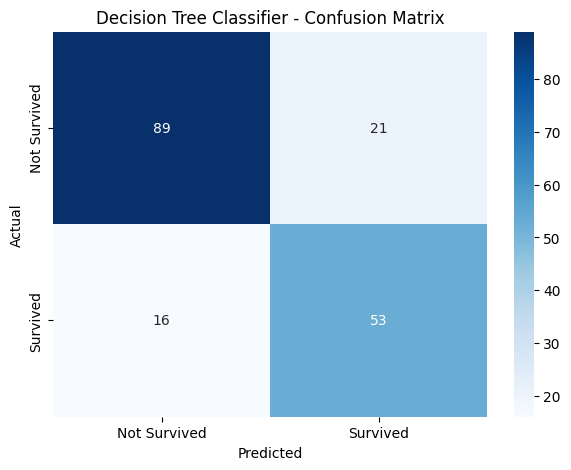

In [24]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Classifier - Confusion Matrix")

plt.show()

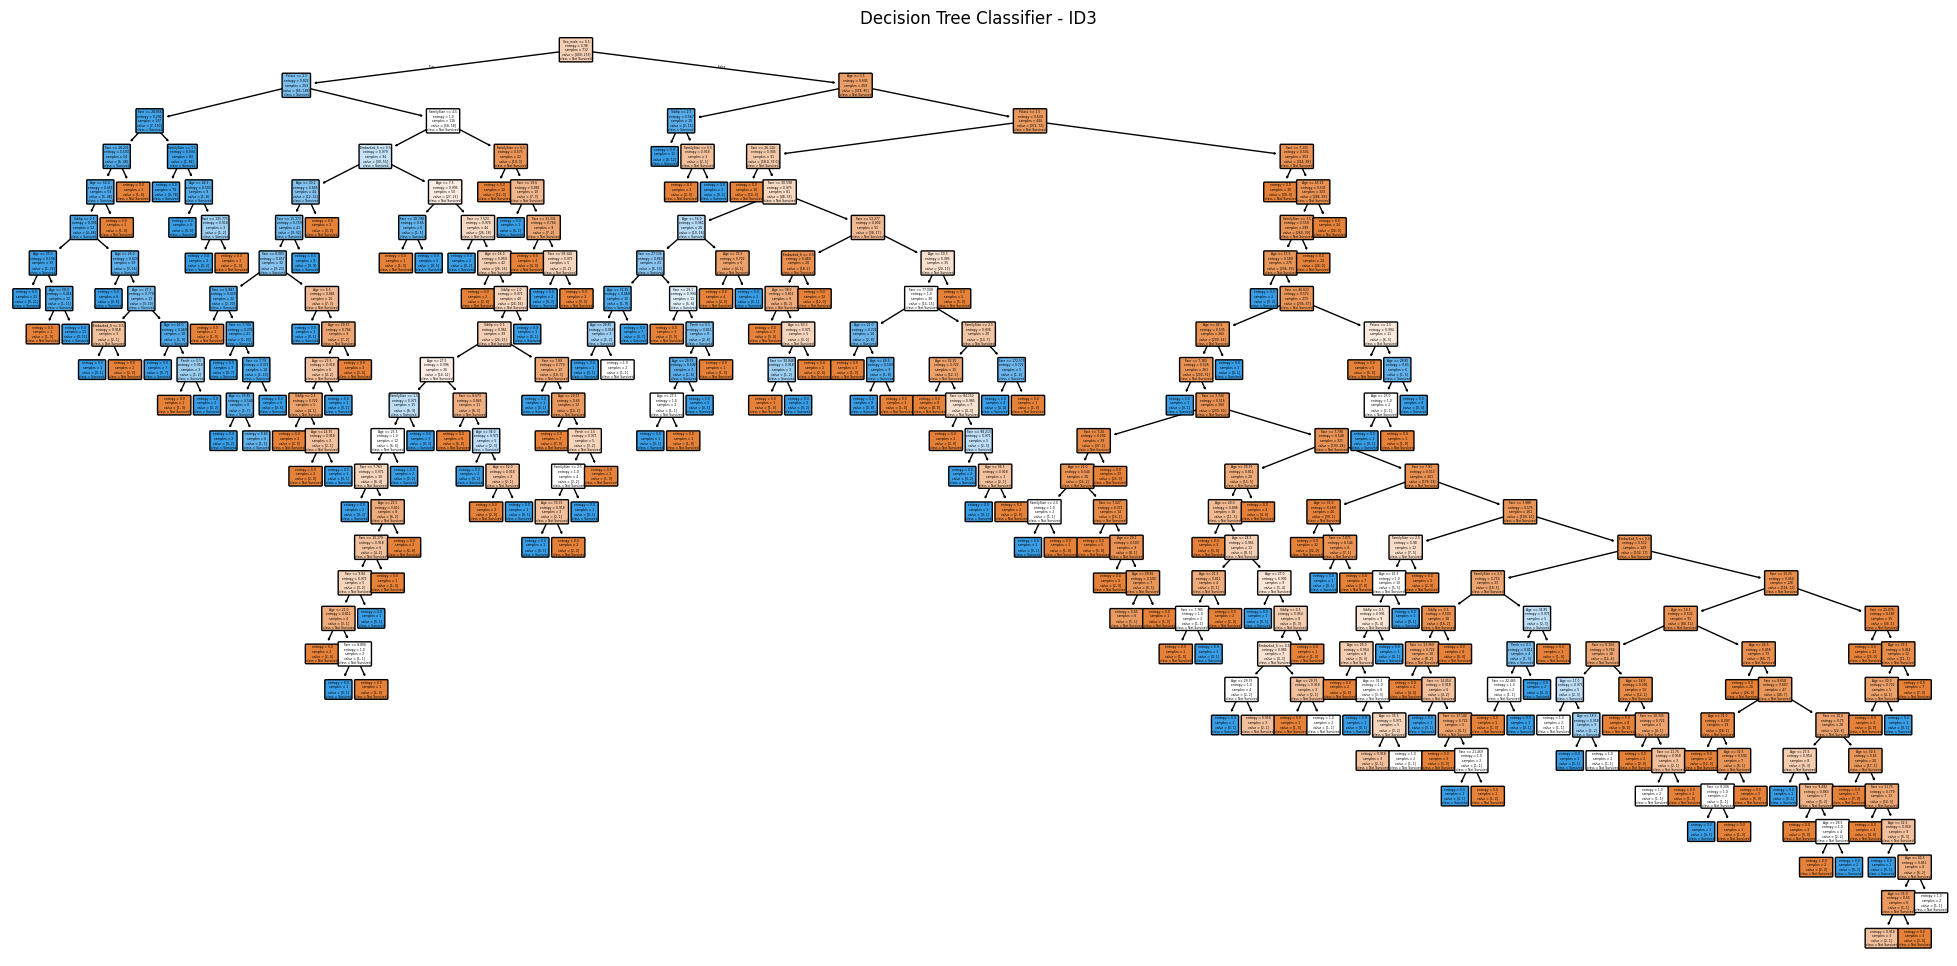

In [27]:
plt.figure(figsize=(25, 12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True, # we can use max_depth = number of level needed to dispaly
)

plt.title("Decision Tree Classifier - ID3")
plt.show()

to see number of leaf nodes and deapth of the tree

In [28]:
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Tree depth: 25
Number of leaves: 161


In [29]:
for feature, importance in zip(
    X.columns,
    dt_model.feature_importances_
):
    print(feature, ":", importance)

Pclass : 0.12252061761510137
Age : 0.2739108602657452
SibSp : 0.02325238763149617
Parch : 0.011018237135905018
Fare : 0.24397443668808458
FamilySize : 0.06352051393255206
Sex_male : 0.2425066436922384
Embarked_Q : 0.0
Embarked_S : 0.019296303038877295


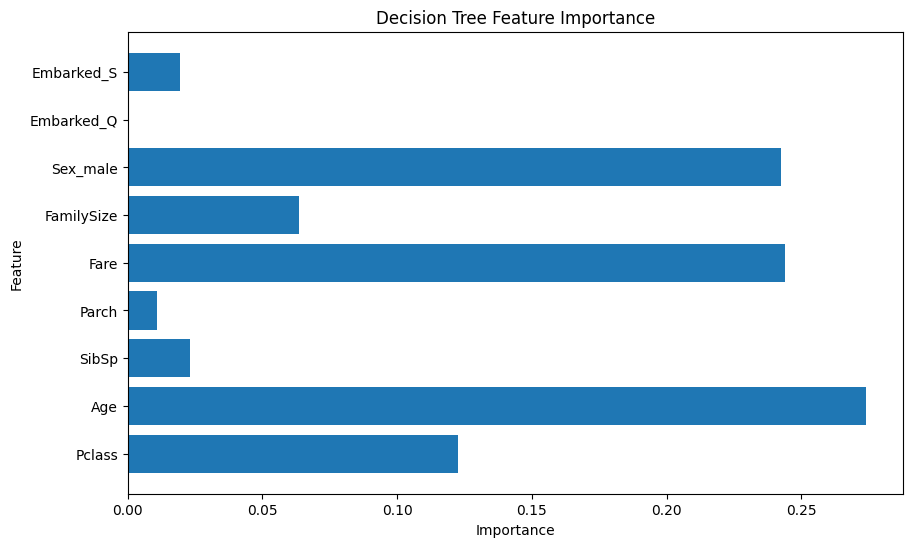

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    X.columns,
    dt_model.feature_importances_
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.show()